# Modulo 8 -- Sesion 6 · Machine Learning No Supervisado
## Cuadernillo del ESTUDIANTE

| | |
|---|---|
| **Sesion** | 6 -- Complemento ML No Supervisado |
| **Dataset** | hr_ibm.csv -- el mismo de siempre |

### Objetivo
Construir un modelo K-Means que segmente automaticamente a los empleados
de TechNova en perfiles de riesgo -- sin necesitar saber quienes rotaron.

El modelo descubrira la estructura sola. Tu trabajo es interpretar
que significa cada grupo en terminos de negocio.

### Como usa este cuadernillo
| Tipo | Que hacer |
|------|-----------|
| Celdas **▶ EJECUTA** | Correr sin modificar |
| Celdas **✏️ TU TURNO** | Completar codigo o responder preguntas |


## Bloque 0 -- ▶ EJECUTA -- Instalacion

In [ ]:
import subprocess, sys
for pkg in ['scikit-learn', 'matplotlib', 'seaborn', 'joblib']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg,
                    '--break-system-packages', '-q'])
print("Dependencias listas.")


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../hr_ibm.csv')
print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")


Dataset: 1470 filas x 35 columnas


## Bloque 1 -- ▶ EJECUTA -- Supervisado vs No supervisado

### La diferencia clave
En S5 entrenamos modelos que SABIAN que empleados habian rotado (Attrition='Yes').
En S6 el modelo NO sabe nada de rotacion -- solo agrupa por similitud.
Lo fascinante: los grupos que emerge suelen capturar el riesgo de rotacion de todas formas.

In [2]:
# La diferencia fundamental entre supervisado y no supervisado
diferencias = {
    'Caracteristica': [
        'Tiene variable objetivo (etiqueta)',
        'Pregunta que responde',
        'Ejemplo en RH',
        'Algoritmo usado en este modulo',
        'Cuando usarlo',
        'Limitacion principal',
    ],
    'Aprendizaje Supervisado (S5)': [
        'SI -- necesita Attrition conocido',
        '¿Este empleado va a renunciar?',
        'Clasificar: va a irse / se queda',
        'Logistic Regression, Decision Tree',
        'Cuando tienes datos historicos etiquetados',
        'Necesitas datos del pasado con la respuesta',
    ],
    'Aprendizaje No Supervisado (S6)': [
        'NO -- no necesita etiquetas',
        '¿Que grupos naturales existen?',
        'Segmentar: perfil A, B, C de empleado',
        'K-Means',
        'Cuando quieres descubrir estructura oculta',
        'Tu interpretas los clusters -- no hay respuesta correcta',
    ]
}

df_dif = pd.DataFrame(diferencias)
print(df_dif.to_string(index=False))
print()
print("CLAVE: En S5 ya SABIAMOS que empleados rotaron (Attrition='Yes').")
print("En S6 le decimos al modelo: 'encuentra grupos sin saber nada de rotacion'.")
print("Sorprendentemente, los clusters que emerge suelen capturar riesgo de rotacion.")


                    Caracteristica                Aprendizaje Supervisado (S5)                          Aprendizaje No Supervisado (S6)
Tiene variable objetivo (etiqueta)           SI -- necesita Attrition conocido                              NO -- no necesita etiquetas
             Pregunta que responde              ¿Este empleado va a renunciar?                           ¿Que grupos naturales existen?
                     Ejemplo en RH            Clasificar: va a irse / se queda                    Segmentar: perfil A, B, C de empleado
    Algoritmo usado en este modulo          Logistic Regression, Decision Tree                                                  K-Means
                     Cuando usarlo  Cuando tienes datos historicos etiquetados               Cuando quieres descubrir estructura oculta
              Limitacion principal Necesitas datos del pasado con la respuesta Tu interpretas los clusters -- no hay respuesta correcta

CLAVE: En S5 ya SABIAMOS que empleados rotaron 

## Bloque 2 -- ▶ EJECUTA -- Preprocesamiento y Regla del Codo

### ¿Por que estandarizar?
MonthlyIncome va de 1,000 a 20,000. JobSatisfaction va de 1 a 4.
Sin estandarizar, el salario dominaria el calculo de distancias
y las otras variables no tendrian efecto.

In [3]:
# ── PASO 1: SELECCION DE VARIABLES PARA CLUSTERING ──────────
# Variables que capturan satisfaccion, experiencia y salario
# (las mismas que usamos en el score manual -- coherencia narrativa)

features_km = [
    'JobSatisfaction',        # satisfaccion con el trabajo (1-4)
    'WorkLifeBalance',        # balance vida-trabajo (1-4)
    'EnvironmentSatisfaction',# satisfaccion con el ambiente (1-4)
    'JobInvolvement',         # involucramiento (1-4)
    'MonthlyIncome',          # salario mensual
    'YearsAtCompany',         # antiguedad
    'Age',                    # edad
]

X_km = df[features_km].copy()
print("Variables seleccionadas para clustering:")
print(X_km.describe().round(2).to_string())


Variables seleccionadas para clustering:
       JobSatisfaction  WorkLifeBalance  EnvironmentSatisfaction  JobInvolvement  MonthlyIncome  YearsAtCompany      Age
count          1470.00          1470.00                  1470.00         1470.00        1470.00         1470.00  1470.00
mean              2.73             2.76                     2.72            2.73        6502.93            7.01    36.92
std               1.10             0.71                     1.09            0.71        4707.96            6.13     9.14
min               1.00             1.00                     1.00            1.00        1009.00            0.00    18.00
25%               2.00             2.00                     2.00            2.00        2911.00            3.00    30.00
50%               3.00             3.00                     3.00            3.00        4919.00            5.00    36.00
75%               4.00             3.00                     4.00            3.00        8379.00            9.00 

In [ ]:
# ── PASO 2: ESTANDARIZACION ──────────────────────────────────
# StandardScaler convierte cada variable a media=0, desviacion=1
# Esto garantiza que todas las variables contribuyan igual al clustering
from IPython.display import display

scaler = StandardScaler()
X_scaler = scaler.fit_transform(X_km)

print("Antes de estandarizar")
display(pd.DataFrame(X_km.values[:3], columns=features_km).round(2))

print("Despues de estandarizar")
display(pd.DataFrame(X_scaler[:3], columns=features_km).round(3))

print("Recordemos que cuando metemos un scaled este nos va a dar media con valores aprox 0 y la desviacion estandar con valores de -1")

Antes de estandarizar


,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,JobInvolvement,MonthlyIncome,YearsAtCompany,Age
0,4,1,2,3,5993,6,41
1,2,3,3,2,5130,10,49
2,3,3,4,2,2090,0,37


Despues de estandarizar


,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,JobInvolvement,MonthlyIncome,YearsAtCompany,Age
0,1.153,-2.494,-0.661,0.380,-0.108,-0.165,0.446
1,-0.661,0.338,0.255,-1.026,-0.292,0.489,1.322
2,0.246,0.338,1.170,-1.026,-0.938,-1.144,0.008


In [8]:
# ── PASO 3: REGLA DEL CODO ───────────────────────────────────
# Inercia = suma de distancias al cuadrado de cada punto a su centroide
# Cuando agregar mas clusters ya no reduce mucho la inercia = codo

inercias = []
silhouette = []
K_range = range(2,10)

#vamos a calcular la invercia para k
print("Calculando inercia para k=2, k=4, K=8")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaler)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_scaler, km.labels_)
    silhouette.append(sil)
    print(f"   k={k}:    ----   inercia = {km.inertia_:.0f}     ------  Silhouettle={sil:.3f}")





Calculando inercia para k=2, k=4, K=8
   k=2:    ----   inercia = 8452     ------  Silhouettle=0.246
   k=3:    ----   inercia = 7494     ------  Silhouettle=0.151
   k=4:    ----   inercia = 6829     ------  Silhouettle=0.146
   k=5:    ----   inercia = 6301     ------  Silhouettle=0.147
   k=6:    ----   inercia = 5888     ------  Silhouettle=0.149
   k=7:    ----   inercia = 5491     ------  Silhouettle=0.149
   k=8:    ----   inercia = 5253     ------  Silhouettle=0.147
   k=9:    ----   inercia = 5051     ------  Silhouettle=0.149


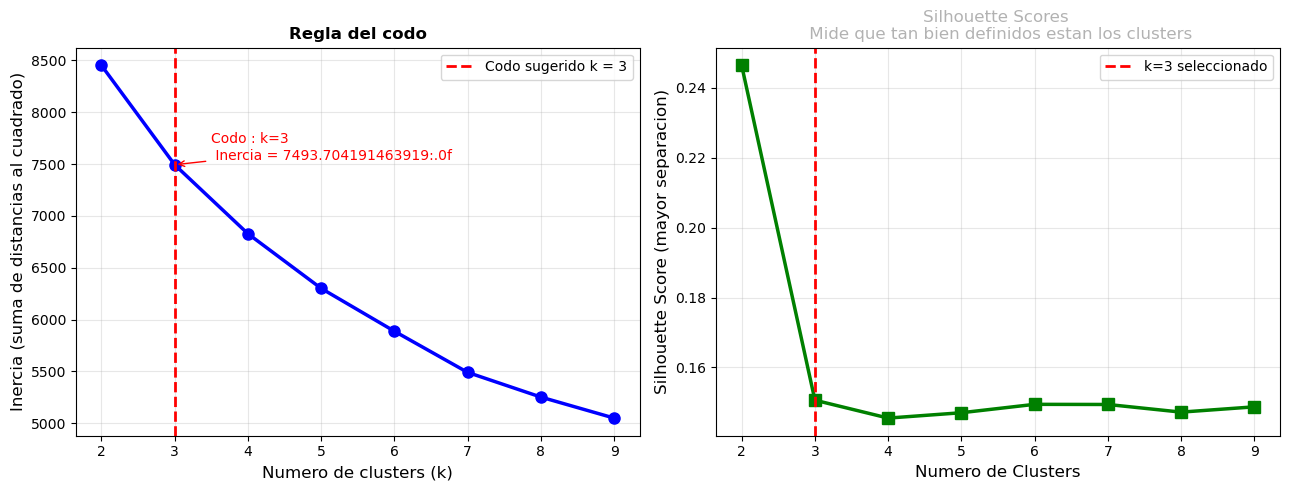

In [10]:
# Grafica del codo + Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Grafica 1: Regla del codo
ax = axes[0]
ax.plot(list(K_range), inercias, 'bo-', lw=2.5, markersize=8)

# Marcar el codo optimo (k=3 o k=4 segun el codo)
k_optimo =3
ax.axvline(k_optimo, color='red', lw=2, linestyle='--', label=f'Codo sugerido k = {k_optimo}')
ax.set_xlabel('Numero de clusters (k)', fontsize=12)
ax.set_ylabel('Inercia (suma de distancias al cuadrado)', fontsize=12)
ax.set_title('Regla del codo', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)


# Anotar el codo
inercia_codo = inercias[k_optimo - 2]
ax.annotate(f'Codo : k={k_optimo} \n Inercia = {inercia_codo}:.0f', 
            xy=(k_optimo, inercia_codo),
            xytext=(k_optimo+0.5, inercia_codo+50),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)



# Grafica 2: Silhouette Score
ax = axes[1]

ax.plot(list(K_range), silhouette, 'gs-', lw=2.5, markersize=8)
ax.axvline(k_optimo, color='red', lw=2, linestyle='--', label=f'k={k_optimo} seleccionado')
ax.set_xlabel('Numero de Clusters', fontsize=12)
ax.set_ylabel('Silhouette Score (mayor separacion)', fontsize=12)
ax.set_title('Silhouette Scores \n Mide que tan bien definidos estan los clusters', fontsize=12, alpha=0.3)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('regla_del_codo.png', dpi=150, bbox_inches='tight')
plt.show()



### ✏️ TU TURNO -- Bloque 2

In [ ]:
# ✏️ TU TURNO -- Bloque 2: Regla del Codo
# PREGUNTA: ¿Donde ves el codo en la grafica generada?
# ¿Cual es el k que elegirías y por que?
# Prueba con k=4 y compara el Silhouette Score con k=3.


# ESCRIBE TU RESPUESTA EN LA CELDA MARKDOWN SIGUIENTE


**Responde aqui:**

¿Donde ves el codo en la grafica? ¿Cual k elegirías para presentar al Director de RH?

*Tu respuesta:*


## Bloque 3 -- ▶ EJECUTA -- K-Means, visualizacion y comparacion

### ¿Que esperar?
Los 3 clusters que emerge tendran caracteristicas distintas de satisfaccion,
salario y antiguedad. Tu tarea es interpretar cada cluster con un nombre de negocio.

In [12]:
# ── ENTRENAR K-MEANS CON k=3 ────────────────────────────────

k_optimo=3

km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
km_final.fit(X_scaler)

df_cluster = df[features_km].copy()
df_cluster['cluster'] = km_final.labels_
df_cluster['EmployeeNumber'] = df['EmployeeNumber'].values
df_cluster['Attrition'] = df['Attrition'].values

print(f"KM entrenado con k:{k_optimo}")
print(f"Distribución de empleados por cluster")
print(df_cluster['cluster'].value_counts().sort_index())

KM entrenado con k:3
Distribución de empleados por cluster
cluster
0    466
1    747
2    257
Name: count, dtype: int64


In [14]:
from IPython.display import display

# ── CARACTERISTICAS MEDIAS POR CLUSTER ──────────────────────
medias = df_cluster.groupby('cluster')[features_km].mean().round(2)
print("Caracteristicas promedio del cluster: ")
display(medias)

# Tasa de rotacion real por cluster
print("\n Tasa de Rotación por cluster: ")
rot_cluster = df_cluster.groupby('cluster')['Attrition'].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f}%"
)
for cluster, tasa in rot_cluster.items():
    n = (df_cluster['cluster'] == cluster).sum()
    print(f"Cluster : {cluster} ::: {tasa} rotacion ({n} empleados)")


Caracteristicas promedio del cluster: 


,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,JobInvolvement,MonthlyIncome,YearsAtCompany,Age
cluster,,,,,,,
0,1.48,2.77,2.75,2.75,4771.32,5.31,34.52
1,3.52,2.76,2.70,2.72,4794.58,5.47,34.80
2,2.69,2.74,2.73,2.72,14608.26,14.54,47.46



 Tasa de Rotación por cluster: 
Cluster : 0 ::: 22.1% rotacion (466 empleados)
Cluster : 1 ::: 15.5% rotacion (747 empleados)
Cluster : 2 ::: 7.0% rotacion (257 empleados)


In [15]:
# ── NOMBRAR LOS CLUSTERS CON LOGICA DE NEGOCIO ───────────────
# Basado en las caracteristicas medias, asignamos nombres
# (el nombre puede variar segun los datos reales del dataset)

nombres_cluster = {
    0: 'Perfil A -- Empleado estable',
    1: 'Perfil B -- Empleado en riesgo',
    2: 'Perfil C -- Empleado de transicion',
}
# NOTA: los clusters pueden aparecer en diferente orden en cada ejecucion.
# Revisar las medias de arriba y reasignar si es necesario.
df_cluster['perfil'] = df_cluster['cluster'].map(nombres_cluster)
print("Asignar los perfiles")

for k, nombre in nombres_cluster.items():
    sub = df_cluster[df_cluster['cluster']==k]
    rot = (sub['Attrition']=='Yes').mean()*100
    print(f"{nombre}: {len(sub)} empleados , {rot:.1f}% rotacion")





Asignar los perfiles
Perfil A -- Empleado estable: 466 empleados , 22.1% rotacion
Perfil B -- Empleado en riesgo: 747 empleados , 15.5% rotacion
Perfil C -- Empleado de transicion: 257 empleados , 7.0% rotacion


In [ ]:
# ── VISUALIZACION CON PCA ────────────────────────────────────
# PCA reduce las 7 dimensiones a 2 para poder graficar
# Los puntos cercanos = empleados similares en las 7 dimensiones
pca = PCA(n_components=2, random_state=42)
coord = pca.fit_transform(X_scaler)

# Grafica 1: clusters K-Means


# Grafica 2: coloreado por Attrition real



In [ ]:
# ── COMPARACION CON SCORE MANUAL DE S5 ──────────────────────


# Score promedio por cluster



# Top 10 del score manual vs cluster de mayor riesgo

print(f"De los top 10 del score manual de S5,")

print()
print("Conclusion: ambos metodos identifican perfiles similares de riesgo.")
print("K-Means lo hace SIN saber que empleados rotaron -- solo por similitud.")


In [ ]:
# ── GUARDAR MODELO K-MEANS ───────────────────────────────────
joblib.dump(km_final, 'modelo_kmeans.pkl')
joblib.dump(scaler,   'scaler_kmeans.pkl')

import json
with open('features_kmeans.json', 'w') as f:
    json.dump(features_km, f)
with open('nombres_clusters.json', 'w') as f:
    json.dump({str(k): v for k,v in nombres_cluster.items()}, f)

print("Modelos guardados:")
print("  modelo_kmeans.pkl")
print("  scaler_kmeans.pkl")
print("  features_kmeans.json")
print("  nombres_clusters.json")


### ✏️ TU TURNO -- Bloque 3

In [ ]:
# ✏️ TU TURNO -- Bloque 3: Interpreta los clusters
# PASO 1: Mira las medias de cada cluster (arriba).
# PASO 2: Asigna un nombre de negocio a cada cluster.
# PASO 3: ¿Que estrategia de RH aplicarías para cada perfil?

# Completa esta tabla con tus observaciones:
print("Completa la siguiente tabla en la celda Markdown siguiente:")
print()
print("| Cluster | Nombre que le darias | Caracteristica clave | Estrategia de RH |")
print("|---------|---------------------|---------------------|-----------------|")
print("| 0       |                     |                     |                 |")
print("| 1       |                     |                     |                 |")
print("| 2       |                     |                     |                 |")

# PREGUNTA FINAL:
# ¿Cual de los 3 enfoques usarias en la vida real?
# a) Score manual (S5) -- reglas del analista
# b) Clasificador ML (S5) -- aprendizaje supervisado
# c) K-Means (S6) -- agrupamiento no supervisado
# ¿O una combinacion? ¿Cual y para que situacion?
print()
print("Escribe tu respuesta en la celda Markdown siguiente.")


**Completa la tabla de interpretacion:**

| Cluster | Nombre que le das | Caracteristica clave | Estrategia de RH |
|---------|-------------------|---------------------|-----------------|
| 0 | | | |
| 1 | | | |
| 2 | | | |

**Pregunta final del modulo:**

¿Cual de los 3 enfoques (Score manual S5, Clasificador ML S5, K-Means S6)
usarías en la vida real y para que situacion especifica?

*Tu respuesta:*


## Bloque 4 -- ▶ EJECUTA -- App Shiny: Segmentador

In [ ]:
# app_kmeans.py -- App Shiny: Segmentador de empleados con K-Means
# Guardar como app_kmeans.py y ejecutar: shiny run app_kmeans.py

APP_CODE = '''
from shiny import App, ui, render
import pandas as pd
import numpy as np
import joblib
import json

# Cargar modelos al arrancar
km_model  = joblib.load("modelo_kmeans.pkl")
scaler    = joblib.load("scaler_kmeans.pkl")

with open("features_kmeans.json") as f:
    feats = json.load(f)
with open("nombres_clusters.json") as f:
    nombres = json.load(f)

perfiles_info = {
    "0": {"color":"#2E7D32","icono":"Estable","accion":"Monitoreo periodico -- mantener condiciones actuales."},
    "1": {"color":"#C62828","icono":"En riesgo","accion":"Revision inmediata -- conversacion de retencion prioritaria."},
    "2": {"color":"#F57F17","icono":"Transicion","accion":"Seguimiento mensual -- revisar carga laboral y plan de carrera."},
}

css_lines = [
    "    body { background:#F4F6F9; font-family:Segoe UI,Arial,sans-serif; }",
    "    .navbar { background:#1F3864 !important; }",
    "    .navbar-brand,.nav-link { color:white !important; font-weight:500; }",
    "    .seg-box { background:white; border-radius:12px; padding:28px;",
    "               box-shadow:0 2px 10px rgba(0,0,0,.12); text-align:center;",
    "               max-width:500px; margin:30px auto; }",
    "    .seg-perfil { font-size:2em; font-weight:bold; margin-bottom:6px; }",
    "    .seg-label  { font-size:.95em; color:#555; }",
    "    .seg-accion { background:#F4F6F9; border-radius:8px; padding:14px;",
    "                  margin-top:16px; font-size:14px; text-align:left; }",
]
css = ui.tags.style(chr(10).join(css_lines))

app_ui = ui.page_navbar(css,
    ui.nav_panel("Segmentador de empleados",
        ui.layout_sidebar(
            ui.sidebar(
                ui.h5("Ingresa el perfil del empleado"),
                ui.input_slider("jobsat", "Satisfaccion laboral (1-4)", 1, 4, 3),
                ui.input_slider("wlb",    "Balance vida-trabajo (1-4)", 1, 4, 3),
                ui.input_slider("envsat", "Sat. del ambiente (1-4)",    1, 4, 3),
                ui.input_slider("jobinv", "Involucramiento (1-4)",      1, 4, 3),
                ui.input_slider("income", "Salario mensual (USD)",
                                1000, 20000, 5000, step=500),
                ui.input_slider("years",  "Anos en la empresa",  0, 40,  3),
                ui.input_slider("age",    "Edad",               18, 60, 30),
                ui.hr(),
                ui.p("El modelo K-Means asignara al empleado al perfil que mas "
                     "se parezca a su segmento natural.",
                     style="font-size:12px;color:#888;"),
            ),
            ui.output_ui("resultado_segmento"),
            ui.output_ui("comparacion_clusters"),
        )
    ),
    ui.nav_panel("Perfil de los 3 segmentos",
        ui.output_ui("descripcion_clusters"),
    ),
    title="TechNova Solutions -- Segmentador de Empleados K-Means",
)

def server(input, output, session):

    @render.ui
    def resultado_segmento():
        fila = pd.DataFrame([[
            input.jobsat(), input.wlb(), input.envsat(), input.jobinv(),
            input.income(), input.years(), input.age()
        ]], columns=feats)
        fila_scaled = scaler.transform(fila)
        cluster_id  = int(km_model.predict(fila_scaled)[0])

        nombre  = nombres.get(str(cluster_id), f"Cluster {cluster_id}")
        info    = perfiles_info.get(str(cluster_id), {})
        color   = info.get("color", "#333")
        accion  = info.get("accion", "Sin recomendacion disponible.")
        icono   = info.get("icono", "")

        # Distancias a los 3 centroides para mostrar certeza
        distancias = km_model.transform(fila_scaled)[0]
        dist_min   = distancias.min()
        certeza    = max(0, (1 - dist_min / distancias.max()) * 100)

        return ui.div(
            ui.div(
                ui.div(nombre, class_="seg-perfil", style=f"color:{color};"),
                ui.div(f"Certeza de asignacion: {certeza:.0f} %", class_="seg-label"),
                ui.div(
                    ui.strong("Recomendacion de accion:"),
                    ui.br(),
                    accion,
                    class_="seg-accion",
                    style=f"border-left:4px solid {color};",
                ),
                class_="seg-box",
                style=f"border-top:6px solid {color};",
            )
        )

    @render.ui
    def comparacion_clusters():
        return ui.div(
            ui.p("Modifica los controles del sidebar para ver como cambia el segmento. "
                 "Intenta un empleado con satisfaccion=1, anos=0 -- "
                 "¿a que perfil lo asigna el modelo?",
                 style="color:#666;font-size:13px;margin-top:8px;max-width:600px;")
        )

    @render.ui
    def descripcion_clusters():
        items = []
        colores = {"0":"#2E7D32","1":"#C62828","2":"#F57F17"}
        descripciones = {
            "0": ("Empleado estable",
                  "Alta satisfaccion laboral y con el ambiente. "
                  "Buen balance vida-trabajo. Lleva varios anos en la empresa. "
                  "Salario por encima del promedio.",
                  "Bajo riesgo de rotacion. Accion: mantener condiciones y "
                  "ofrecer oportunidades de crecimiento para retener a largo plazo."),
            "1": ("Empleado en riesgo",
                  "Baja satisfaccion laboral. Posiblemente hace horas extra. "
                  "Pocos anos en la empresa. Salario por debajo del promedio del nivel.",
                  "Alto riesgo de rotacion. Accion: conversacion de retencion "
                  "inmediata. Revisar condiciones de trabajo y compensacion."),
            "2": ("Empleado de transicion",
                  "Satisfaccion media. Recien llegado o en cambio de rol. "
                  "Aun no consolida pertenencia a la empresa.",
                  "Riesgo medio. Accion: seguimiento mensual, asignar mentor, "
                  "revisar plan de carrera en los primeros 3 anos."),
        }
        for k, (nombre, desc, accion) in descripciones.items():
            color = colores[k]
            items.append(ui.div(
                ui.h4(nombre, style=f"color:{color};border-left:4px solid {color};"
                                    "padding-left:10px;"),
                ui.p(desc),
                ui.div(ui.strong("Accion recomendada: "), accion,
                       style=f"background:#F4F6F9;padding:10px;border-radius:6px;"
                             f"border-left:3px solid {color};font-size:14px;"),
                style="margin-bottom:24px;"
            ))
        return ui.div(*items, style="max-width:700px;margin:20px auto;")

app = App(app_ui, server)
'''

with open('app_kmeans.py', 'w', encoding='utf-8') as f:
    f.write(APP_CODE)
print("App guardada: app_kmeans.py")
print("Para ejecutar: shiny run app_kmeans.py")


### Prueba la app

1. Ejecuta: `shiny run app_kmeans.py`
2. Ingresa un empleado con satisfaccion=1, anos=0, income=2000 -- ¿que perfil le asigna?
3. Ingresa uno con satisfaccion=4, anos=15, income=15000 -- ¿cambia el perfil?
4. Revisa la segunda pestana -- ¿la descripcion del perfil coincide con lo que esperabas?


---
### Autoevaluacion

| Criterio | Cumple |
|----------|--------|
| Variables estandarizadas con StandardScaler | ☐ |
| Regla del codo graficada con inercia y Silhouette | ☐ |
| K optimo identificado y justificado | ☐ |
| K-Means entrenado y clusters asignados | ☐ |
| Clusters interpretados con nombres de negocio | ☐ |
| Visualizacion PCA con clusters y Attrition | ☐ |
| Comparacion con score manual de S5 ejecutada | ☐ |
| App Shiny funcionando | ☐ |
| Tabla de interpretacion de clusters completada | ☐ |
| Pregunta final del modulo respondida | ☐ |
